In [5]:
import sys
sys.path.append('../src')

import pandas as pd
from backtest.engine import BacktestEngine
from strategies.mean_reversion import generate_mr_signals

import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
df = pd.read_csv("../data/1Min/SPY_1Min_2024-10-01_2024-12-31.csv", index_col = "timestamp", parse_dates = True)

df = df.between_time("09:30", "16:00")

print(f"Total bars: {len(df)}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
df.head()

Total bars: 19404
Date range: 2024-10-01 09:30:00+00:00 to 2024-12-30 16:00:00+00:00


,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2024-10-01 09:30:00+00:00,573.34,573.34,573.34,573.34,446.0,7.0,573.340000
2024-10-01 09:31:00+00:00,573.33,573.33,573.33,573.33,422.0,8.0,573.330000
2024-10-01 09:32:00+00:00,573.30,573.30,573.30,573.30,322.0,5.0,573.300000
2024-10-01 09:34:00+00:00,573.36,573.36,573.36,573.36,215.0,9.0,573.360000
2024-10-01 09:36:00+00:00,573.28,573.39,573.28,573.39,858.0,7.0,573.359945


In [7]:
signals = generate_mr_signals(df)

engine = BacktestEngine(initial_cash = 10000, fill_timing = "next_open")
results = engine.run(df, signals)

print(f"Initial Cash: ${results['initial_cash']:,.2f}")
print(f"Final Value: ${results['final_value']:,.2f}")
print(f"Total Return: {results['total_return']:.2%}")
print(f"Total Trades: {len(results['trades'])}")

Initial Cash: $10,000.00
Final Value: $6,787.38
Total Return: -32.13%
Total Trades: 405


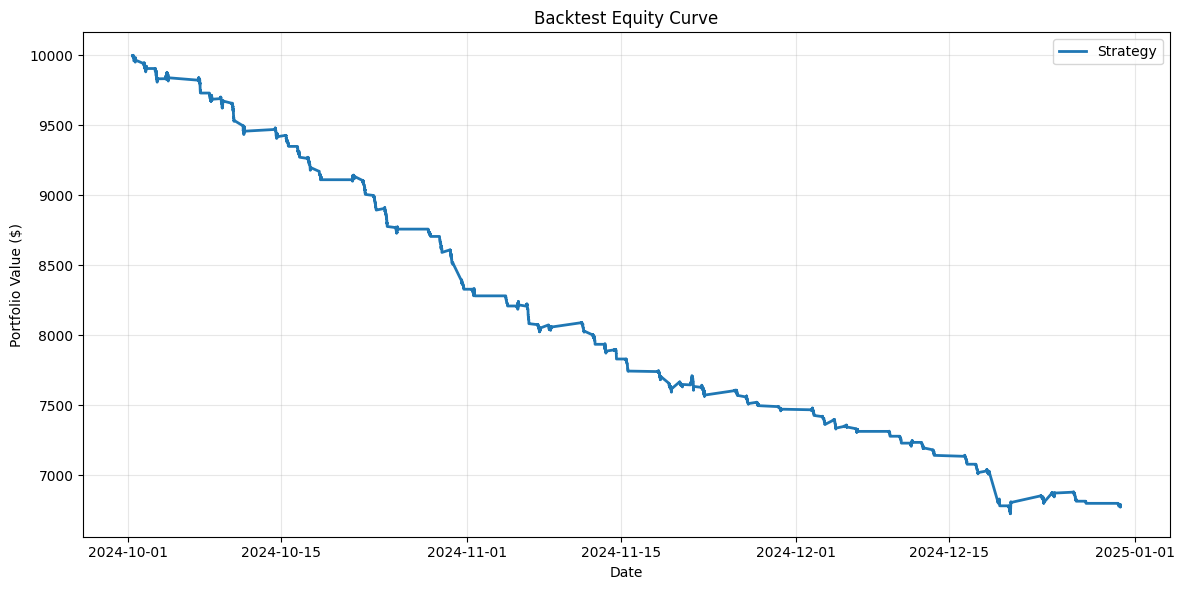

In [8]:
equity = results['equity_curve'].set_index('timestamp')

plt.figure(figsize=(12, 6))
plt.plot(equity.index, equity['equity'], label='Strategy', linewidth=2)
plt.title('Backtest Equity Curve')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()